In [1]:
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env")  # notebook lives in tracer/, .env is here

required = ["GROQ_API_KEY", "TAVILY_API_KEY", "ANTHROPIC_API_KEY"]
missing = [k for k in required if not os.getenv(k)]
if missing:
    print(f"WARNING: missing env vars: {missing}")
else:
    print("All keys loaded.")

All keys loaded.


## 2. State & Schemas

In [2]:
from typing import TypedDict
from pydantic import BaseModel


class ResearchState(TypedDict):
    question: str
    search_plan: list[str]
    search_results: list[dict]
    sources_read: list[dict]
    synthesis: str
    citations: list[dict]
    failures: list[dict]


class Citation(BaseModel):
    id: int
    url: str
    title: str
    snippet: str
    relevance_score: float = 0.0


class Section(BaseModel):
    heading: str
    content: str
    citation_ids: list[int]


class ResearchReport(BaseModel):
    title: str
    summary: str
    sections: list[Section]
    citations: list[Citation]
    confidence_note: str = ""
    data_gaps: list[str] = []


print("State and schemas defined.")

State and schemas defined.


## 3. Tools (Tavily search + page fetcher)

In [3]:
import time
from datetime import datetime, timezone

import requests
from bs4 import BeautifulSoup
from tavily import TavilyClient

_tavily_client = None


def tavily_search(query: str, max_results: int = 5) -> list[dict]:
    global _tavily_client
    if _tavily_client is None:
        _tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = _tavily_client.search(query=query, max_results=max_results)
    return [
        {
            "query": query,
            "url": r.get("url", ""),
            "title": r.get("title", ""),
            "snippet": r.get("content", ""),
            "score": r.get("score", 0.0),
        }
        for r in response.get("results", [])
    ]


_STRIP_TAGS = ["nav", "footer", "header", "script", "style", "aside", "noscript"]


def fetch_page(url: str) -> tuple[dict | None, dict | None]:
    ts = datetime.now(timezone.utc).isoformat()

    def _fail(ftype, msg):
        return {"node": "read_sources", "type": ftype, "url": url,
                "message": msg, "recovery_action": "skipped", "timestamp": ts}

    try:
        resp = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
    except requests.exceptions.Timeout:
        return None, _fail("timeout", "No response after 10s")
    except requests.exceptions.RequestException as e:
        return None, _fail("request_error", str(e))

    if "text/html" not in resp.headers.get("Content-Type", ""):
        return None, _fail("non_html", resp.headers.get("Content-Type", ""))
    if resp.status_code == 403:
        return None, _fail("http_403", "403 Forbidden")
    if resp.status_code == 404:
        return None, _fail("http_404", "404 Not Found")
    if not resp.ok:
        return None, _fail(f"http_{resp.status_code}", f"HTTP {resp.status_code}")

    soup = BeautifulSoup(resp.text, "html.parser")
    for tag in soup(_STRIP_TAGS):
        tag.decompose()
    text = " ".join(soup.get_text(separator=" ").split())
    title = soup.title.string.strip() if soup.title and soup.title.string else ""

    if len(text) < 200:
        return None, _fail("js_rendered", f"Only {len(text)} chars after strip")
    if len(text) < 500:
        return None, _fail("paywall_suspected", f"Only {len(text)} chars")

    return {"url": url, "title": title, "content": text[:8000], "fetched_at": ts}, None


print("Tools defined.")

Tools defined.


## 4. Nodes & Tracer

In [4]:
import sys
import json
import importlib
from datetime import datetime, timezone

from langchain_groq import ChatGroq
from langchain_anthropic import ChatAnthropic
sys.path.insert(0, "..")
import sdk.tracer_callback
importlib.reload(sdk.tracer_callback)
from sdk.tracer_callback import CustomTracer

tracer = CustomTracer(
    endpoint=os.getenv("TRACER_ENDPOINT", "http://localhost:8000"),
    project=os.getenv("TRACER_NAME", "test_tracer"),
    api_key=os.getenv("TRACER_API_KEY", "change-me"),
)


def _llm():
    return ChatGroq(
        model="llama-3.3-70b-versatile",
        api_key=os.environ["GROQ_API_KEY"],
    )


# ── plan_searches ──────────────────────────────────────────────────────────────
def plan_searches(state: ResearchState) -> dict:
    prompt = (
        f"You are a research planner. Given the question below, generate 3-5 targeted search queries.\n"
        f"Return ONLY a JSON array of strings, no explanation.\n\n"
        f"Question: {state['question']}"
    )
    raw = _llm().invoke(prompt).content.strip()
    try:
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        queries = json.loads(raw)
        if not isinstance(queries, list):
            raise ValueError
    except Exception:
        queries = [state["question"]]
    print(f"  [plan_searches] queries={queries}")
    return {"search_plan": queries}


# ── execute_searches ───────────────────────────────────────────────────────────
def execute_searches(state: ResearchState) -> dict:
    failures = list(state.get("failures") or [])
    results = []
    for query in state.get("search_plan") or []:
        try:
            results.extend(tavily_search(query, max_results=5))
        except Exception as e:
            failures.append({"node": "execute_searches", "message": str(e),
                              "timestamp": datetime.now(timezone.utc).isoformat()})
    print(f"  [execute_searches] +{len(results)} results")
    return {"search_results": results, "failures": failures}


# ── read_sources ───────────────────────────────────────────────────────────────
def read_sources(state: ResearchState) -> dict:
    failures = list(state.get("failures") or [])
    sources_read = []
    candidates = sorted(state.get("search_results") or [], key=lambda r: r.get("score", 0.0), reverse=True)
    for result in candidates:
        if len(sources_read) >= 3:
            break
        page, failure = fetch_page(result.get("url", ""))
        if failure:
            failures.append(failure)
        else:
            sources_read.append(page)
    print(f"  [read_sources] fetched={len(sources_read)}")
    return {"sources_read": sources_read, "failures": failures}


# ── synthesize ─────────────────────────────────────────────────────────────────
def synthesize(state: ResearchState) -> dict:
    sources_read = state.get("sources_read") or []
    if not sources_read:
        report = ResearchReport(
            title="Research could not be completed",
            summary="No sources were successfully retrieved.",
            sections=[], citations=[], data_gaps=[],
        )
        return {"synthesis": report.model_dump_json(), "citations": []}

    sources_text = "\n---\n".join(
        f"[{i+1}] Title: {s['title']}\nURL: {s['url']}\nContent:\n{s['content']}"
        for i, s in enumerate(sources_read)
    )
    prompt = (
        f"You are a research analyst. Write a structured research report answering the question below.\n"
        f"Use only information from the provided sources. Include inline citation IDs.\n\n"
        f"Question: {state['question']}\n\nSources:\n{sources_text}"
    )
    try:
        report: ResearchReport = _llm().with_structured_output(ResearchReport).invoke(prompt)
    except Exception:
        raw = _llm().invoke(prompt).content.strip()
        try:
            report = ResearchReport(**json.loads(raw))
        except Exception:
            report = ResearchReport(title=state["question"], summary=raw[:500], sections=[], citations=[])
    citations = [c.model_dump() for c in report.citations]
    print(f"  [synthesize] title='{report.title}' sections={len(report.sections)}")
    return {"synthesis": report.model_dump_json(), "citations": citations}


print("Nodes and tracer defined.")

Nodes and tracer defined.


## 5. Build Graph

In [5]:
from langgraph.graph import StateGraph, END

builder = StateGraph(ResearchState)

builder.add_node("plan_searches", plan_searches)
builder.add_node("execute_searches", execute_searches)
builder.add_node("read_sources", read_sources)
builder.add_node("synthesize", synthesize)

builder.set_entry_point("plan_searches")
builder.add_edge("plan_searches", "execute_searches")
builder.add_edge("execute_searches", "read_sources")
builder.add_edge("read_sources", "synthesize")
builder.add_edge("synthesize", END)

graph = builder.compile()
print("Graph compiled.")

Graph compiled.


## 6. Visualize Graph

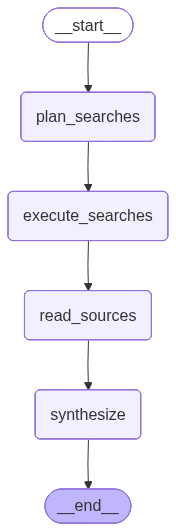

In [6]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## 7. Invoke with one question

In [7]:
initial_state: ResearchState = {
    "question": "what is context engineering in ai agent",
    "search_plan": [],
    "search_results": [],
    "sources_read": [],
    "synthesis": "",
    "citations": [],
    "failures": [],
}

print(f"Running: '{initial_state['question']}'\n")
result = graph.invoke(initial_state, config={"callbacks": [tracer]})

print("\n── Summary ──")
print(f"sources read: {len(result.get('sources_read', []))}")
print(f"failures    : {len(result.get('failures', []))}")
print(f"citations   : {len(result.get('citations', []))}")
print(f"traces sent to: {tracer._endpoint} (project={tracer._project})")

Running: 'what is context engineering in ai agent'

  [plan_searches] queries=['context engineering in AI agents', 'context-aware AI systems', 'engineering context for artificial intelligence', 'AI agent context modeling', 'context-based decision making in AI']
  [execute_searches] +25 results
  [read_sources] fetched=3
  [synthesize] title='Context Engineering in AI Agents' sections=5

── Summary ──
sources read: 3
failures    : 0
citations   : 3
traces sent to: http://localhost:8000 (project=test_tracer)


## 8. Print Report

In [8]:
import json

synthesis = result.get("synthesis", "")
try:
    report = json.loads(synthesis)
    print(f"Title   : {report['title']}")
    print(f"Summary : {report['summary']}\n")
    for s in report.get("sections", []):
        print(f"### {s['heading']}")
        print(s["content"])
        print()
    print("Citations:")
    for c in report.get("citations", []):
        score = c.get('relevance_score', 0)
        print(f"  [{c['id']}] {c['title']} ({score:.2f}) — {c['url']}")
except Exception:
    print(synthesis)

Title   : Context Engineering in AI Agents
Summary : Context engineering is the process of designing and managing the context in which AI agents operate, including the information, tools, and instructions provided to the agent. It is a critical aspect of building reliable and effective AI agents, as it determines the agent's ability to understand and respond to its environment.

### Introduction
Context engineering is the delicate art and science of filling the context window with just the right information for the next step [1].

### Context Window
The context window is the amount of text the model can read at once, and it limits how much you can show the model, shapes what it pays attention to, and sets cost and latency because tokens in and out drive usage [2].

### Components of Context
Context is the set of inputs an agent can see and use to reason, including system instructions, user prompts, memory, knowledge base, tools, and outputs [2].

### Context Engineering vs. Prompt Engi

In [9]:
# import anthropic
# client = anthropic.Client(api_key=os.environ["ANTHROPIC_API_KEY"])

In [10]:
# message = client.messages.create(
#     model="claude-haiku-4-5-20251001",
#     max_tokens=1024,
#     temperature=1,
#     messages=[{"role": "user", "content": "what is the speed of light in m/s?"}],
#     thinking={
#         "type": "disabled"
#     }
# )
# print(message)

In [11]:
# """
# Message(id='msg_01SHLz8US4nX9Xupper5K5ER', container=None, content=[TextBlock(citations=None, text="The speed of light in vacuum is approximately **299,792,458 m/s**, often rounded to **3 × 10⁸ m/s** or **3.0 × 10⁸ m/s** for practical purposes.\n\nIt's commonly denoted by the letter **c** in physics equations.", type='text')], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=18, output_tokens=76, output_tokens_details=None, server_tool_use=None, service_tier='standard'))
# """
# message.usage.input_tokens + message.usage.output_tokens

In [12]:
# from groq import Groq

# client = Groq()
# completion = client.chat.completions.create(
#     model="openai/gpt-oss-20b",
#     messages=[
#       {
#         "role": "user",
#         "content": "what is the speed of light in m/s?"
#       }
#     ],
#     temperature=1,
#     max_completion_tokens=1024,
#     top_p=1,
#     stream=False,
#     stop=None
# )

# completion.usage.completion_tokens


In [ ]:
# """ 
# ChatCompletion(id='chatcmpl-b1785368-10d4-4a00-afc5-344fea816ae2', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='The speed of light in a vacuum is exactly **299,792,458\u202fm/s**.', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning='The user asks: "what is the speed of light in m/s?" Simple answer: 299,792,458 m/s. They might want the exact value, because it\'s defined. Provide that. Probably a short answer.', tool_calls=None))], created=1781863054, model='openai/gpt-oss-20b', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_84bb35977d', usage=CompletionUsage(completion_tokens=76, prompt_tokens=81, total_tokens=157, completion_time=0.078021936, completion_tokens_details=CompletionTokensDetails(reasoning_tokens=47), prompt_time=0.003838674, prompt_tokens_details=None, queue_time=0.315249015, total_time=0.08186061), usage_breakdown=None, x_groq=XGroq(id='req_01kvfn0z5nfg2t6hs8xqqb3qpb', debug=None, seed=26660343, usage=None))
# """


# print(completion.usage.completion_tokens)
# print(completion.usage.total_tokens)
# print(completion.usage.total_time)


Tracer ingest 422: {"detail":[{"type":"dict_type","loc":["body","inputs"],"msg":"Input should be a valid dictionary","input":"You are a research analyst. Write a structured research report answering the question below.\nUse only information from the provided sources. Include inline citation IDs.\n\nQuestion: what is context engineering in ai agent\n\nSources:\n[1] Title: Deep Dive into Context Engineering for Agents\nURL: https://galileo.ai/blog/context-engineering-for-agents\nContent:\nDeep Dive into Context Engineering for Agents Back Sep 24, 2025 Deep Dive into Context Engineering for Agents Pratik Bhavsar Evals & Leaderboards @ Galileo Labs Production AI agents typically process 100 tokens of input for every token they generate. That's the reality that Manus discovered after millions of user interactions. \"Context engineering is effectively the #1 job of engineers building AI agents\" - Cognition The industry is slowly waking up to this fundamental truth: managing what goes into y